# ZeroER++ — block-filter tuning (phase 1)

One Optuna study per dataset on the seeded ~30% partition, named `<dataset>_block-filter`, saved to the same `outputs/optuna.db`. Single objective: **max F1**.

Only the blocking & filtering stage is searched — k-NN candidate generation over precomputed LLM record embeddings (`datasets/embeddings/<dataset>/<model>_{left,right}.npy`, row-aligned with the tables); the ZeroER matcher itself runs stock.

In [1]:
from estimator import ZeroEREstimator, BlockFeatureCache
from data import DATASETS, DEFAULT_TUNE_FRACTION, load_data, embedding_models
from metrics import precision_recall_f1, blocking_recall
from tuning import tune_all
from reporting import show_results

## Search space & budget

Every embedding model found on disk enters the space (discovered per dataset in the objective); `seed_trials` enqueues each model once so none is left to sampling luck.

In [1]:
SEED = 0
EXPERIMENT = "block-filter"   # study names: <dataset>_block-filter[_full]
SPACE = {                     # blocking/filtering knobs only — the matcher stays stock ZeroER
    # "embedding_model" is added per dataset in the objective: every model
    # discovered under datasets/embeddings/<dataset>/ is a candidate.
    "top_k": (1, 10),                          # neighbours kept per entity
    "similarity_distance": ["cosine", "euclidean"],
}
N_STARTUP_TRIALS = 8           # TPE random warm-up before it models the space
N_TRIALS = None                # derived per dataset: warm-up + 1/3 of (models x top_k x distance)

## Objective

The per-experiment trial — declared here, not in `tuning`, so a new experiment is just a copy-and-tweak of this cell. It returns **F1 only** and carries its own `directions`, `experiment` (the study-name suffix) and `seed_trials` (per-model coverage guarantee); `make_objective` binds it to `SPACE`/`SEED` for the runners.

In [3]:
class BlockFilterObjective:
    """Single-objective trial: **max F1**, searching only blocking & filtering —
    k-NN candidate generation over precomputed LLM record embeddings. The
    ZeroER matcher runs stock (default ``c_bay``/``max_iter``), so any F1 gain
    is attributable to the blocking stage alone.

    One ``Data`` is loaded per instance and reused across trials. Blocking and
    feature generation run once per (model, distance) at the top_k upper bound
    and are sliced per trial (``BlockFeatureCache`` — k-NN lists are nested in
    top_k), so most trials cost only the EM. ``get_params`` *is* the search
    space; ``seed_trials`` guarantees every embedding model is visited at
    least once before TPE takes over.
    """
    directions = ["maximize"]                 # F1 only
    experiment = EXPERIMENT                   # -> study "<dataset>_block-filter"

    def __init__(self, dataset, space, seed=0, partition=True):
        self.dataset = dataset
        self.source_trial = None              # set by retrain_full to stamp each full trial
        self.data = load_data(dataset, partition=partition, seed=seed)
        self.attributes = DATASETS[dataset]["attributes"]
        models = embedding_models(dataset)
        if not models:
            raise FileNotFoundError(
                f"no precomputed embeddings under datasets/embeddings/{dataset}/")
        self.space = dict(space, embedding_model=models)   # per-dataset model list
        self.cache = BlockFeatureCache(dataset, self.data, self.attributes,
                                       k_max=space["top_k"][1], n_jobs=-1)
        frac = DATASETS[dataset].get("tune_fraction", DEFAULT_TUNE_FRACTION)
        scope = f"partition (frac={frac})" if partition else "full data"
        print(f"    {scope}: {self.data.num_of_entities_1}+{self.data.num_of_entities_2}"
              f" entities, {len(self.data.ground_truth)} matches, "
              f"{len(models)} embedding models", flush=True)

    def seed_trials(self):
        # one enqueued config per model (median top_k, cosine) — "go through
        # all the models" holds even under a sampled, non-grid budget
        mid_k = sum(self.space["top_k"]) // 2
        return [dict(embedding_model=m, top_k=mid_k, similarity_distance="cosine")
                for m in self.space["embedding_model"]]

    def get_params(self, trial):
        s = self.space
        return dict(
            embedding_model=trial.suggest_categorical("embedding_model", s["embedding_model"]),
            top_k=trial.suggest_int("top_k", *s["top_k"]),
            similarity_distance=trial.suggest_categorical("similarity_distance", s["similarity_distance"]),
        )

    def __call__(self, trial):
        p = self.get_params(trial)
        est = ZeroEREstimator(                        # stock ZeroER matcher
            blocker="precomputed", cache=self.cache,
            vectorizer=p["embedding_model"], top_k=p["top_k"],
            similarity_distance=p["similarity_distance"],
            attributes=self.attributes)
        graph = est.fit_predict(self.data)
        _, _, f1 = precision_recall_f1(graph, self.data)
        trial.set_user_attr("candset_size", est.candset_size)
        trial.set_user_attr("pair_completeness",
                            round(blocking_recall(est.blocks, self.data), 4))
        # one-time (model, distance) blocking+feature cost; repeated on hits
        trial.set_user_attr("blocking_seconds", est.blocking_seconds)
        trial.set_user_attr("em_seconds", round(est.matcher.em_time, 3))
        if self.source_trial is not None:
            trial.set_user_attr("source_trial", self.source_trial)
        return f1


def make_objective(dataset, partition=True):                 # factory the runners call per dataset
    return BlockFilterObjective(dataset, SPACE, SEED, partition=partition)

## Run phase 1 — tune on the partition

Resumable: re-running continues the existing studies.

In [ ]:
tune_all(make_objective, n_trials=N_TRIALS, n_startup_trials=N_STARTUP_TRIALS, seed=SEED)

## Results

Best configs + the trials in the two F1 trade-off planes. The winner per study is tie-broken toward cheaper blocking: trials within `F1_TIE_DELTA` (0.005) of the best F1 count as ties and the smallest candidate set wins (`utils.front_trials`). Only `partition` results exist until `zeroer.ipynb` retrains the `full` ones.

In [4]:
try:
    from IPython.display import display
except ImportError:
    display = print

=== partition: 5 Pareto-optimal configs across 5 dataset(s) ===


,dataset,phase,F1,candset_size,blocking_recall,embedding_model,top_k,similarity_distance,blocking_seconds,em_seconds
0,abt_buy,partition,0.1610,2961,0.1459,microsoft_harrier-oss-v1-27b,9,euclidean,25.270,0.578
1,amazon_googleproducts,partition,0.2593,4850,0.9769,Qwen_Qwen3-Embedding-8B,5,cosine,233.123,0.475
2,dblp_acm,partition,0.9925,688,0.9985,codefuse-ai_F2LLM-v2-4B,1,euclidean,16.050,0.483
3,dblp_scholar,partition,0.8421,19309,0.9658,Octen_Octen-Embedding-8B,1,cosine,1585.260,12.146
4,fodors_zagats,partition,1.0000,200,1.0000,nvidia_llama-embed-nemotron-8b,2,cosine,1.908,0.224


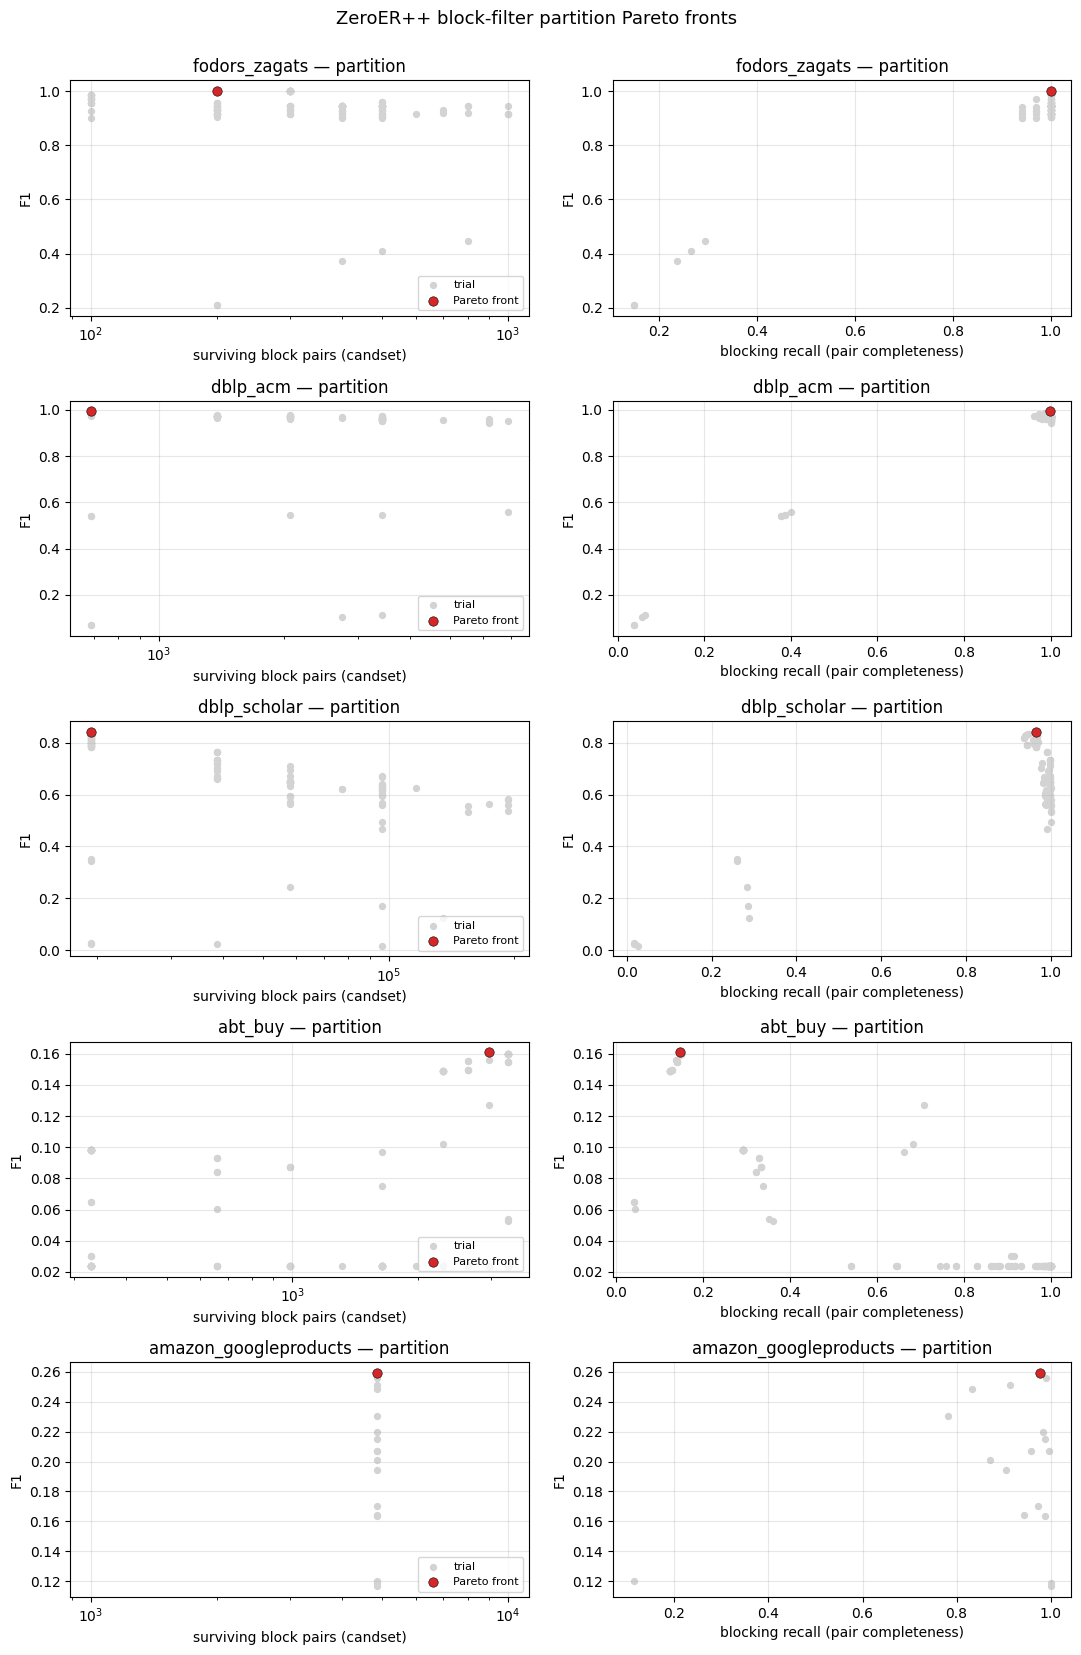

=== full: 5 Pareto-optimal configs across 5 dataset(s) ===


,dataset,phase,F1,candset_size,blocking_recall,embedding_model,top_k,similarity_distance,blocking_seconds,em_seconds,source_trial
0,abt_buy,full,0.0746,9828,0.0793,microsoft_harrier-oss-v1-27b,9,euclidean,28.539,1.001,114
1,amazon_googleproducts,full,0.1617,16130,0.9377,Qwen_Qwen3-Embedding-8B,5,cosine,985.161,10.253,2
2,dblp_acm,full,0.9883,2294,0.9928,codefuse-ai_F2LLM-v2-4B,1,euclidean,24.562,0.288,77
3,dblp_scholar,full,0.8203,64263,0.9663,Octen_Octen-Embedding-8B,1,cosine,474.222,11.051,30
4,fodors_zagats,full,0.9955,662,1.0000,nvidia_llama-embed-nemotron-8b,2,cosine,1.430,0.308,25


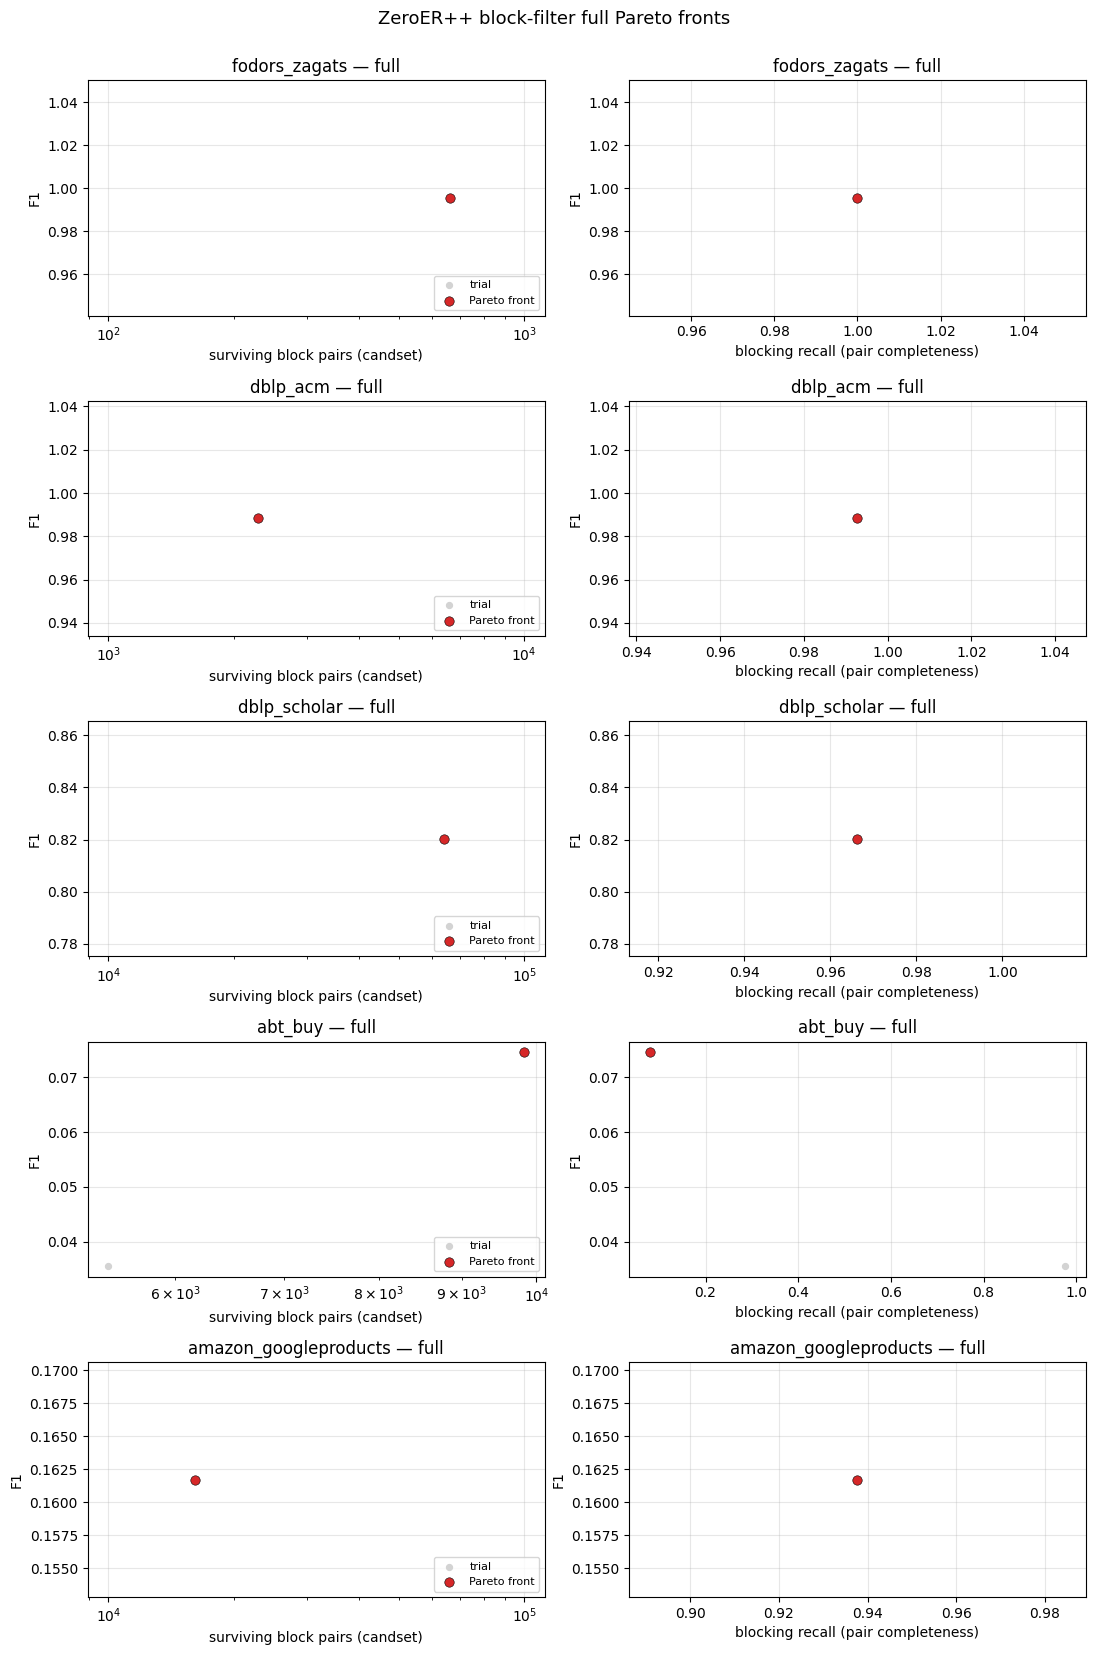

In [5]:
show_results(experiment=EXPERIMENT)

## Blocking-only sweep - full factorial

Isolates the **candidate-generation** stage: every cell of `20 embedding models x top_k in [1, 100] x k-NN direction` is evaluated on the **full** dataset (no tuning partition — there is nothing to overfit when the whole grid is enumerated), across all five benchmarks.

This is a *sweep*, not a search. Nothing is sampled: results are written straight into the study with `add_trial`, so no sampler is ever consulted and the recorded front is exact rather than approximated.

**Cost.** k-NN lists are nested in `top_k`, so one exact faiss search per (model, direction) at `k_max` serves all 100 k-values by slicing: the grid costs 2 searches per model, not 200. PC at every k then comes from a single pass over the ground truth (the rank at which each gold pair enters the candidate set, as a cumulative histogram), so the 100 k-values are essentially free. The real cost is streaming ~13 GB of embeddings off disk — 11 GB of it `dblp_scholar` — so the sweep is resumable and holds one model's vectors at a time.

**Axes.** `similarity_distance` is deliberately *absent*. The stored vectors are already L2-normalised, so `||u-v||^2 = 2 - 2*u.v` and the cosine and Euclidean k-NN rankings are identical — verified as the same neighbour matrices in the same order.

**What is stored.** The raw counts `tp`, `candset_size`, `n_gold` rather than the ratios, so PC / PQ / RR / mAP are all derivable afterwards and adding a metric never means re-running. Objective values are `(pair_completeness, candset_size)` with directions `["maximize", "minimize"]` — a *labelling* choice, not an optimisation one: it lets `study.best_trials` hand back the exact PC-vs-cost Pareto front over the completed grid.

In [1]:
import time
from collections import Counter

import numpy as np
import optuna
from optuna.distributions import CategoricalDistribution, IntDistribution

from data import DATASETS, embedding_models, load_data, load_embeddings
from estimator import nn_search
from tuning import STORAGE

K_MAX = 100                        # k range of AutoER / of UniBlocker's mAP
QUERIED_SIDES = ["right", "left"]
BLOCKING_EXPERIMENT = "blocking"   # -> study "<dataset>_blocking"
BLOCKING_DIRECTIONS = ["maximize", "minimize"]   # (pair completeness, candset)


def _gold_ranks(nbrs, data, queried_side, limit):
    """1-based rank at which each gold pair enters the candidate set
    (``nbrs.shape[1] + 1`` = never retrieved).

    Sweeping ``top_k`` never needs the block dicts themselves: k-NN lists are
    nested in k, so a gold pair is in the candidate set at every k >= its rank.
    One pass over the ground truth therefore yields PC at *every* k as a
    cumulative histogram — O(|gold|) rather than O(|gold| x k_max), which is
    what makes 100 k-values per search essentially free.
    """
    n_k = nbrs.shape[1]
    ranks = np.full(len(data.ground_truth), n_k + 1, dtype=np.int64)
    for r, (_, (id1, id2)) in enumerate(data.ground_truth.iterrows()):
        i1 = data._ids_mapping_1[id1]                 # left-table row index
        i2 = data._ids_mapping_2[id2] - limit         # right-table row index
        row, target = (i2, i1) if queried_side == "right" else (i1, i2)
        hit = np.flatnonzero(nbrs[row] == target)
        if hit.size:
            ranks[r] = hit[0] + 1
    return ranks


def run_blocking_sweep(dataset, k_max=K_MAX, queried_sides=QUERIED_SIDES,
                       storage=STORAGE):
    """Evaluate every (embedding model, top_k, k-NN direction) cell on one
    dataset and record the results in the ``<dataset>_blocking`` study.

    Exhaustive, not searched: one exact faiss search per (model, direction) at
    ``k_max`` serves all k by slicing, so the grid costs 2 searches per model.
    Trials are written with ``add_trial`` — the values are already known, so no
    sampler is ever consulted. Resumable: (model, direction) pairs already in
    the study are skipped, which matters because the sweep streams ~13 GB of
    embeddings off disk.

    Recorded per trial: the raw counts (``tp``, ``candset_size``, ``n_gold``)
    rather than the ratios, so PC / PQ / RR / mAP are all derivable afterwards
    and a new metric never means re-running. Timings are per (model, direction)
    — one search is amortised over all ``k_max`` trials — and split into disk
    load vs faiss (index + query), since the load cost is an artifact of this
    repo's offline-embedding setup rather than of the blocking method.
    """
    data = load_data(dataset, partition=False)        # full data, no partition
    models = embedding_models(dataset)
    limit, n_gold = data.dataset_limit, len(data.ground_truth)
    n_side = {"right": data.num_of_entities_2, "left": data.num_of_entities_1}

    study = optuna.create_study(
        study_name=f"{dataset}_{BLOCKING_EXPERIMENT}",
        storage=storage, load_if_exists=True, directions=BLOCKING_DIRECTIONS)
    counts = Counter((t.params["embedding_model"], t.params["queried_side"])
                     for t in study.trials)
    partial = {cell: n for cell, n in counts.items() if n != k_max}
    if partial:
        raise RuntimeError(
            f"{study.study_name}: {len(partial)} cell(s) do not hold exactly "
            f"{k_max} trials, e.g. {dict(list(partial.items())[:3])} — either a "
            "run was interrupted mid-write, or the study was built with a "
            "different k_max. Resuming would leave a truncated or double-counted "
            "k-sweep, so delete the study (optuna.delete_study) and re-run.")
    done = set(counts)
    dists = dict(
        embedding_model=CategoricalDistribution(models),
        top_k=IntDistribution(1, k_max),
        queried_side=CategoricalDistribution(queried_sides),
    )

    print(f"=== {dataset}: {data.num_of_entities_1}+{data.num_of_entities_2} "
          f"entities, {n_gold} matches, {len(models)} models "
          f"({len(done)}/{len(models) * len(queried_sides)} cells done) ===",
          flush=True)

    for model in models:
        vectors = load_seconds = None
        for d in queried_sides:
            if (model, d) in done:
                continue
            if vectors is None:
                t0 = time.time()
                vectors = load_embeddings(dataset, model, data)
                load_seconds = round(time.time() - t0, 3)
            v1, v2 = vectors
            index_side, query_side = (v1, v2) if d == "right" else (v2, v1)

            t0 = time.time()
            nbrs = nn_search(index_side, query_side, k_max, "cosine")
            faiss_seconds = round(time.time() - t0, 3)

            # candset = n_queried x k holds only if a row never repeats a
            # neighbour; exact search guarantees it, so assert rather than
            # pay O(n.k) to count distinct pairs at every k.
            srt = np.sort(nbrs, axis=1)
            assert not (srt[:, 1:] == srt[:, :-1]).any(), "duplicate neighbours"

            tp_at_k = np.cumsum(np.bincount(
                _gold_ranks(nbrs, data, d, limit),
                minlength=nbrs.shape[1] + 2)[1:nbrs.shape[1] + 1])

            trials = []
            for k, tp in enumerate(tp_at_k, start=1):
                tp, candset = int(tp), int(n_side[d]) * k
                trials.append(optuna.trial.create_trial(
                    params=dict(embedding_model=model, top_k=k, queried_side=d),
                    distributions=dists,
                    values=[tp / n_gold, float(candset)],
                    user_attrs=dict(
                        tp=tp, n_gold=n_gold, candset_size=candset,
                        pair_completeness=round(tp / n_gold, 6),
                        pair_quality=round(tp / candset, 6),
                        load_seconds=load_seconds, faiss_seconds=faiss_seconds,
                        dim=int(v1.shape[1]),
                        n_left=int(data.num_of_entities_1),
                        n_right=int(data.num_of_entities_2),
                    )))
            study.add_trials(trials)
            print(f"  {model:40} {d:5} PC@1={tp_at_k[0] / n_gold:.4f} "
                  f"PC@{len(tp_at_k)}={tp_at_k[-1] / n_gold:.4f} "
                  f"load={load_seconds}s faiss={faiss_seconds}s", flush=True)
            del nbrs, srt
        del vectors
    return study


/home/mdarm/miniconda3/envs/pyjedai/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-08-06 22:54:37,166	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
for _dataset in DATASETS:
    run_blocking_sweep(_dataset)

[I 2026-08-06 22:54:46,735] A new study created in RDB with name: fodors_zagats_blocking


=== fodors_zagats: 533+331 entities, 112 matches, 20 models (0/40 cells done) ===
  Octen_Octen-Embedding-8B                 right PC@1=1.0000 PC@100=1.0000 load=0.02s faiss=0.047s
  Octen_Octen-Embedding-8B                 left  PC@1=1.0000 PC@100=1.0000 load=0.02s faiss=0.035s
  Qwen_Qwen3-Embedding-4B                  right PC@1=1.0000 PC@100=1.0000 load=0.01s faiss=0.013s
  Qwen_Qwen3-Embedding-4B                  left  PC@1=0.9911 PC@100=1.0000 load=0.01s faiss=0.012s
  Qwen_Qwen3-Embedding-8B                  right PC@1=1.0000 PC@100=1.0000 load=0.026s faiss=0.022s
  Qwen_Qwen3-Embedding-8B                  left  PC@1=1.0000 PC@100=1.0000 load=0.026s faiss=0.019s
  bge_large                                right PC@1=1.0000 PC@100=1.0000 load=0.008s faiss=0.007s
  bge_large                                left  PC@1=1.0000 PC@100=1.0000 load=0.008s faiss=0.009s
  codefuse-ai_F2LLM-v2-14B                 right PC@1=0.9911 PC@100=1.0000 load=0.02s faiss=0.027s
  codefuse-ai_F2LLM-v2-

[I 2026-08-06 22:55:38,722] A new study created in RDB with name: dblp_acm_blocking


=== dblp_acm: 2616+2294 entities, 2224 matches, 20 models (0/40 cells done) ===
  Octen_Octen-Embedding-8B                 right PC@1=0.9888 PC@100=1.0000 load=0.093s faiss=0.535s
  Octen_Octen-Embedding-8B                 left  PC@1=0.9910 PC@100=1.0000 load=0.093s faiss=0.527s
  Qwen_Qwen3-Embedding-4B                  right PC@1=0.9879 PC@100=1.0000 load=0.077s faiss=0.373s
  Qwen_Qwen3-Embedding-4B                  left  PC@1=0.9906 PC@100=1.0000 load=0.077s faiss=0.381s
  Qwen_Qwen3-Embedding-8B                  right PC@1=0.9883 PC@100=1.0000 load=0.053s faiss=0.522s
  Qwen_Qwen3-Embedding-8B                  left  PC@1=0.9892 PC@100=1.0000 load=0.053s faiss=0.517s
  bge_large                                right PC@1=0.9856 PC@100=1.0000 load=0.039s faiss=0.166s
  bge_large                                left  PC@1=0.9865 PC@100=1.0000 load=0.039s faiss=0.169s
  codefuse-ai_F2LLM-v2-14B                 right PC@1=0.9915 PC@100=1.0000 load=0.087s faiss=0.601s
  codefuse-ai_F2LLM-

[I 2026-08-06 22:56:41,815] A new study created in RDB with name: dblp_scholar_blocking


=== dblp_scholar: 2616+64263 entities, 5347 matches, 20 models (0/40 cells done) ===
  Octen_Octen-Embedding-8B                 right PC@1=0.9643 PC@100=0.9985 load=0.331s faiss=10.788s
  Octen_Octen-Embedding-8B                 left  PC@1=0.4434 PC@100=0.9993 load=0.331s faiss=10.39s
  Qwen_Qwen3-Embedding-4B                  right PC@1=0.9626 PC@100=0.9972 load=0.327s faiss=6.953s
  Qwen_Qwen3-Embedding-4B                  left  PC@1=0.4414 PC@100=0.9989 load=0.327s faiss=6.48s
  Qwen_Qwen3-Embedding-8B                  right PC@1=0.9660 PC@100=0.9976 load=0.32s faiss=11.264s
  Qwen_Qwen3-Embedding-8B                  left  PC@1=0.4438 PC@100=0.9991 load=0.32s faiss=10.819s
  bge_large                                right PC@1=0.9658 PC@100=0.9998 load=0.155s faiss=3.304s
  bge_large                                left  PC@1=0.4406 PC@100=0.9983 load=0.155s faiss=2.708s
  codefuse-ai_F2LLM-v2-14B                 right PC@1=0.9637 PC@100=0.9991 load=0.619s faiss=13.125s
  codefuse-ai_

[I 2026-08-06 23:01:34,511] A new study created in RDB with name: abt_buy_blocking


=== abt_buy: 1081+1092 entities, 1097 matches, 20 models (0/40 cells done) ===
  Octen_Octen-Embedding-8B                 right PC@1=0.8077 PC@100=1.0000 load=0.02s faiss=0.111s
  Octen_Octen-Embedding-8B                 left  PC@1=0.7794 PC@100=1.0000 load=0.02s faiss=0.103s
  Qwen_Qwen3-Embedding-4B                  right PC@1=0.8149 PC@100=1.0000 load=0.03s faiss=0.059s
  Qwen_Qwen3-Embedding-4B                  left  PC@1=0.7867 PC@100=1.0000 load=0.03s faiss=0.067s
  Qwen_Qwen3-Embedding-8B                  right PC@1=0.8113 PC@100=1.0000 load=0.032s faiss=0.128s
  Qwen_Qwen3-Embedding-8B                  left  PC@1=0.7730 PC@100=1.0000 load=0.032s faiss=0.142s
  bge_large                                right PC@1=0.7612 PC@100=1.0000 load=0.008s faiss=0.035s
  bge_large                                left  PC@1=0.7302 PC@100=0.9991 load=0.008s faiss=0.035s
  codefuse-ai_F2LLM-v2-14B                 right PC@1=0.8259 PC@100=1.0000 load=0.036s faiss=0.143s
  codefuse-ai_F2LLM-v2-14

[I 2026-08-06 23:02:22,130] A new study created in RDB with name: amazon_googleproducts_blocking


=== amazon_googleproducts: 1363+3226 entities, 1300 matches, 20 models (0/40 cells done) ===
  Octen_Octen-Embedding-8B                 right PC@1=0.8031 PC@100=0.9992 load=0.034s faiss=0.314s
  Octen_Octen-Embedding-8B                 left  PC@1=0.6400 PC@100=0.9985 load=0.034s faiss=0.31s
  Qwen_Qwen3-Embedding-4B                  right PC@1=0.7762 PC@100=0.9977 load=0.037s faiss=0.212s
  Qwen_Qwen3-Embedding-4B                  left  PC@1=0.6254 PC@100=0.9962 load=0.037s faiss=0.234s
  Qwen_Qwen3-Embedding-8B                  right PC@1=0.6877 PC@100=0.9938 load=0.039s faiss=0.32s
  Qwen_Qwen3-Embedding-8B                  left  PC@1=0.6177 PC@100=0.9977 load=0.039s faiss=0.32s
  bge_large                                right PC@1=0.7108 PC@100=0.9962 load=0.02s faiss=0.099s
  bge_large                                left  PC@1=0.5800 PC@100=0.9985 load=0.02s faiss=0.096s
  codefuse-ai_F2LLM-v2-14B                 right PC@1=0.8500 PC@100=0.9985 load=0.059s faiss=0.394s
  codefuse-a

### Blocking KPIs

Everything below is *derived* from the stored counts, so a new metric never means re-running the grid.

Per cell: **PC** = `tp/n_gold` (recall), **PQ** = `tp/candset` (precision), **RR** = `1 - candset/(n_left*n_right)`.

Per (dataset, model, queried side): **AP** — area under the PC-vs-PQ curve over the k sweep, i.e. UniBlocker's mAP, in the standard IR form `sum_k (PC_k - PC_{k-1})*PQ_k` anchored at `PC_0 = 0`. Anchoring integrates only between the swept endpoints scores a blocker that already reaches PC=1 at k=1 as *zero*, because its PC never moves. AP is bounded by `n_gold/n_queried`, so **nAP** rescales it to `[0,1]` for cross-dataset comparison. **PC@{1,5,10}** reproduces the fixed-k benchmark table format; **k\*** / **candset@k\*** give the smallest candidate set reaching the target recall, which is the protocol that compares blocking *cost at equal quality*.

Across datasets: **mean rank** (assumption-free — only the per-dataset ordering transfers), **wins**, and **mean nAP**. Rank and nAP disagreeing means a model is winning on a subset rather than uniformly — the dataset-specificity that AutoER argues makes a single universal recommendation unsafe.

/home/mdarm/miniconda3/envs/pyjedai/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== 20000 cells over 5 dataset(s), 20 models, top_k <= 100, queried ['left', 'right'] ===

--- abt_buy (top 5 by nAP; k* = smallest k reaching PC >= 0.95; nAP spread 0.551, 1/20 models tied at top) ---


,dataset,model,queried_side,AP,nAP,PC_max,F_max,k_F,PC@1,PC@5,PC@10,k*,candset@k*,faiss_s,load_s,dim
0,abt_buy,tencent_KaLM-Embedding-Gemma3-12B-2511,right,0.8084,0.8084,1.0,0.9949,8,0.8669,0.9891,0.9982,2.0,2184.0,0.088,0.022,3840
1,abt_buy,microsoft_harrier-oss-v1-27b,right,0.7884,0.7884,1.0,0.9954,8,0.8523,0.9927,1.0000,3.0,3276.0,0.118,0.030,5376
2,abt_buy,microsoft_harrier-oss-v1-0.6b,right,0.7788,0.7788,1.0,0.9944,11,0.8459,0.9881,0.9973,3.0,3276.0,0.027,0.009,1024
3,abt_buy,e5_instruct,right,0.7620,0.7620,1.0,0.9944,12,0.8359,0.9836,0.9945,3.0,3276.0,0.034,0.012,1024
4,abt_buy,codefuse-ai_F2LLM-v2-8B,right,0.7598,0.7598,1.0,0.9945,9,0.8332,0.9799,0.9982,3.0,3276.0,0.104,0.029,4096



--- amazon_googleproducts (top 5 by nAP; k* = smallest k reaching PC >= 0.95; nAP spread 0.525, 1/20 models tied at top) ---


,dataset,model,queried_side,AP,nAP,PC_max,F_max,k_F,PC@1,PC@5,PC@10,k*,candset@k*,faiss_s,load_s,dim
0,amazon_googleproducts,codefuse-ai_F2LLM-v2-14B,right,0.3144,0.7802,0.9985,0.9955,9,0.8500,0.9869,0.9977,3.0,9678.0,0.394,0.059,5120
1,amazon_googleproducts,codefuse-ai_F2LLM-v2-8B,right,0.3045,0.7556,0.9992,0.9948,11,0.8285,0.9885,0.9969,3.0,9678.0,0.320,0.037,4096
2,amazon_googleproducts,codefuse-ai_F2LLM-v2-4B,right,0.3031,0.7521,0.9985,0.9959,7,0.8269,0.9900,0.9977,3.0,9678.0,0.210,0.039,2560
3,amazon_googleproducts,tencent_KaLM-Embedding-Gemma3-12B-2511,right,0.2941,0.7297,0.9985,0.9947,7,0.8115,0.9869,0.9954,3.0,9678.0,0.300,0.050,3840
4,amazon_googleproducts,Octen_Octen-Embedding-8B,right,0.2875,0.7133,0.9992,0.9921,10,0.8031,0.9738,0.9915,4.0,12904.0,0.314,0.034,4096


...

,dataset,model,queried_side,AP,nAP,PC_max,F_max,k_F,PC@1,PC@5,PC@10,k*,candset@k*,faiss_s,load_s,dim
0,dblp_scholar,e5_instruct,right,0.0794,0.9549,1.0000,0.9987,4,0.9699,0.9993,0.9994,1.0,64263.0,3.108,0.208,1024
1,dblp_scholar,e5_large_v2,right,0.0794,0.9540,1.0000,0.9989,4,0.9693,0.9996,1.0000,1.0,64263.0,3.079,0.127,1024
2,dblp_scholar,tencent_KaLM-Embedding-Gemma3-12B-2511,right,0.0792,0.9520,0.9993,0.9978,4,0.9684,0.9974,0.9981,1.0,64263.0,10.081,0.468,3840
3,dblp_scholar,microsoft_harrier-oss-v1-27b,right,0.0789,0.9487,0.9991,0.9976,4,0.9663,0.9970,0.9976,1.0,64263.0,13.873,0.609,5376
4,dblp_scholar,bge_large,right,0.0789,0.9484,0.9998,0.9984,5,0.9658,0.9987,0.9993,1.0,64263.0,3.304,0.155,1024



--- fodors_zagats (top 5 by nAP; k* = smallest k reaching PC >= 0.95; nAP spread 0.327, 15/20 models tied at top) ---


,dataset,model,queried_side,AP,nAP,PC_max,F_max,k_F,PC@1,PC@5,PC@10,k*,candset@k*,faiss_s,load_s,dim
0,fodors_zagats,Octen_Octen-Embedding-8B,left,0.2101,1.0,1.0,0.9985,1,1.0,1.0,1.0,1.0,533.0,0.035,0.020,4096
1,fodors_zagats,Octen_Octen-Embedding-8B,right,0.3384,1.0,1.0,0.9991,1,1.0,1.0,1.0,1.0,331.0,0.047,0.020,4096
2,fodors_zagats,Qwen_Qwen3-Embedding-4B,right,0.3384,1.0,1.0,0.9991,1,1.0,1.0,1.0,1.0,331.0,0.013,0.010,2560
3,fodors_zagats,Qwen_Qwen3-Embedding-8B,left,0.2101,1.0,1.0,0.9985,1,1.0,1.0,1.0,1.0,533.0,0.019,0.026,4096
4,fodors_zagats,Qwen_Qwen3-Embedding-8B,right,0.3384,1.0,1.0,0.9991,1,1.0,1.0,1.0,1.0,331.0,0.022,0.026,4096



=== cross-dataset leaderboard (best queried side per dataset) ===


,model,mean_rank,wins,mean_nAP,mean_PC1,datasets,faiss_s,dim
0,tencent_KaLM-Embedding-Gemma3-12B-2511,3.4,2,0.8961,0.9281,5,2.1726,3840
1,e5_instruct,3.4,3,0.8684,0.9085,5,0.6824,1024
2,microsoft_harrier-oss-v1-27b,3.8,1,0.8865,0.9214,5,3.0150,5376
3,codefuse-ai_F2LLM-v2-14B,4.2,2,0.8934,0.9268,5,2.8678,5120
4,codefuse-ai_F2LLM-v2-8B,5.0,1,0.8900,0.9239,5,2.3884,4096
5,codefuse-ai_F2LLM-v2-4B,6.4,1,0.8822,0.9188,5,1.4928,2560
6,microsoft_harrier-oss-v1-0.6b,6.8,1,0.8770,0.9151,5,0.6710,1024
7,e5_large_v2,6.8,1,0.8387,0.8873,5,0.6672,1024
8,Octen_Octen-Embedding-8B,7.0,1,0.8733,0.9132,5,2.3574,4096
9,Qwen_Qwen3-Embedding-4B,8.0,1,0.8673,0.9089,5,1.5236,2560


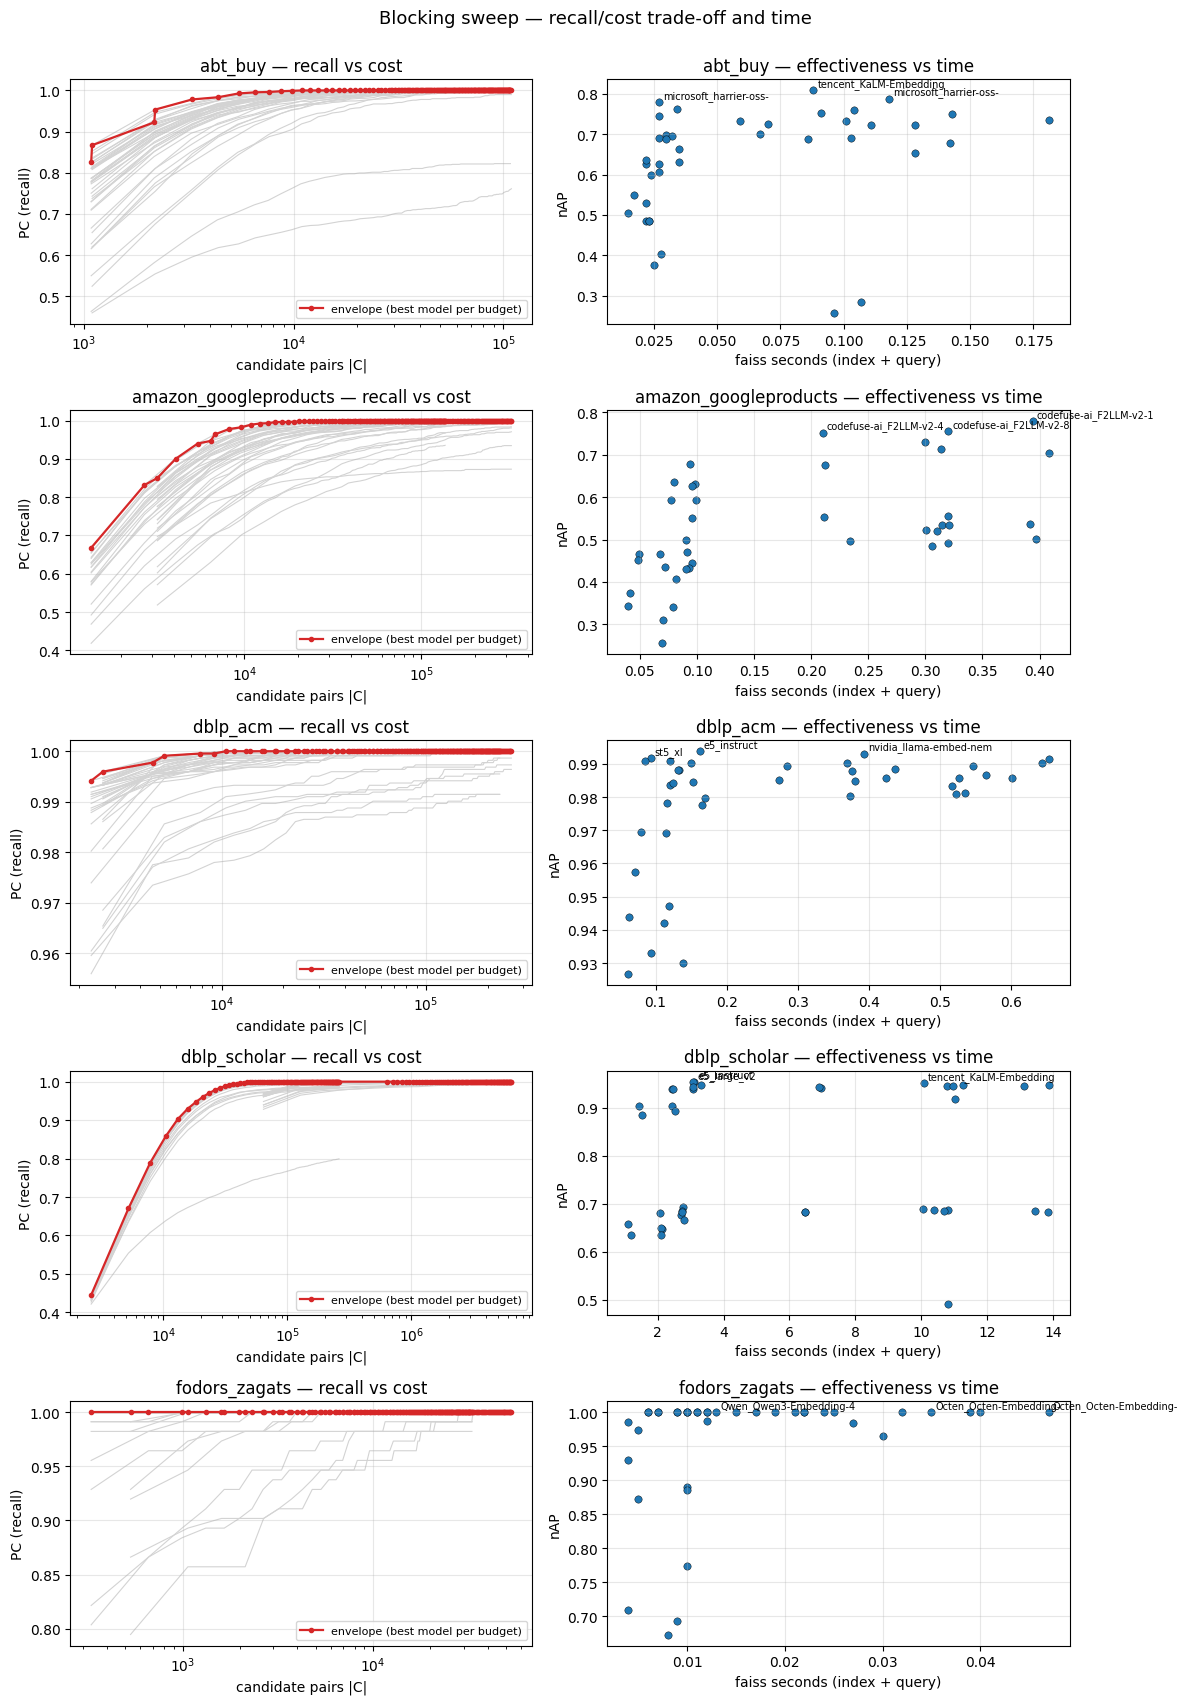

In [ ]:
from reporting import blocking_report

summary = blocking_report()          # per-dataset tables, leaderboard, trade-off plots

### vs literature

Published `PC/PQ` at the smallest `K` reaching `PC ≥ 90%`, querying TableA
(UniBlocker Tables 3–4); ours below, same protocol. Full tables:
`msc-thesis/wiki` → [[llm-embedder-blocking-benchmark]].

| Dataset | STransformer | Sudowoodo | UniBlocker | Sparkly | ours |
|---|---|---|---|---|---|
| fodors-zagats | 93.75/9.85 k=2 | 99.11/20.83 k=1 | 100.00/21.01 k=1 | 100.00/21.01 k=1 | 100.00/21.01 k=1 |
| dblp-acm | 95.28/81.00 k=1 | 97.21/82.65 k=1 | 99.19/84.33 k=1 | 98.74/83.94 k=1 | 99.37/84.48 k=1 |
| dblp-scholar | 91.49/23.38 k=8 | 90.01/2.16 k=85 | 91.55/31.19 k=6 | 92.16/31.40 k=6 | 92.76/31.60 k=6 |
| abt-buy | 90.52/7.07 k=13 | 90.52/15.31 k=6 | 93.16/31.51 k=3 | 92.80/31.39 k=3 | 92.25/46.81 k=2 |
| amazon-google | 90.46/6.64 k=13 | 90.23/7.17 k=12 | 90.38/17.24 k=5 | 91.62/17.48 k=5 | 91.85/21.90 k=4 |

One model (KaLM-Gemma3-12B) on all five, untrained: beats UniBlocker on abt-buy
(k=2 vs 3) and amazon-google (k=4 vs 5), +0.2/+0.4 PQ at equal k on the
bibliographic pair, ties on fodors-zagats (21.01 = 112/533 is the k=1 ceiling).
NLSHBlock (supervised, test splits) F1 at its own targets: AB 91.6 @89% ·
AG 16.2 @97% · DA 65.0 @99% · DS 7.9 @97%.

Compare on PC/PQ at a stated `k` only — UniBlocker's mAP does not follow from
its own formula (fodors implies 21.01, printed 60.51). Collections match ours
except dblp-scholar gold (5,438 vs 5,347) and abt-buy (±1).

### Pending

- Embedding-creation time + index size — measured separately; until then no
  efficiency claim holds against a 110M-backbone method (`faiss_s` is index +
  query only; backbones here span 22M–14B).
- End-to-end pipeline runtime at fixed recall, training charged in (SC-Block's
  figure of merit).
- Re-encode instruction-tuned models with their query/document prompts —
  nemotron is nAP 1.000 on fodors and worst-of-20 on abt-buy, which reads as
  mis-invocation.
- Untested: whether table pre-training still adds on top of a 2025 backbone.

In [ ]:
from reporting import literature_report

kpis = literature_report()      # protocols A / B / C + the efficiency ranking

/home/mdarm/miniconda3/envs/pyjedai/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== A. recall-threshold protocol (PC/PQ at smallest k reaching PC >= 90%, querying TableA=left) ===
    ours = tencent_KaLM-Embedding-Gemma3-12B-2511, one model on every dataset; oracle = best model per dataset (not comparable, shown as the selection gap)


,dataset,DeepBlocker,Sudowoodo,STransformer,UniBlocker,Sparkly,ours,oracle,vs UniBlocker
0,fodors_zagats,100.00/21.01 k=1,99.11/20.83 k=1,93.75/9.85 k=2,100.00/21.01 k=1,100.00/21.01 k=1,100.00/21.01 k=1,100.00/21.01 k=1,tie
1,dblp_acm,97.39/82.80 k=1,97.21/82.65 k=1,95.28/81.00 k=1,99.19/84.33 k=1,98.74/83.94 k=1,99.37/84.48 k=1,99.60/84.67 k=1,+0.2 PQ at k=1
2,dblp_scholar,90.35/20.52 k=9,90.01/2.16 k=85,91.49/23.38 k=8,91.55/31.19 k=6,92.16/31.40 k=6,92.76/31.60 k=6,90.26/36.90 k=5,+0.4 PQ at k=6
3,abt_buy,90.06/1.02 k=90,90.52/15.31 k=6,90.52/7.07 k=13,93.16/31.51 k=3,92.80/31.39 k=3,92.25/46.81 k=2,92.25/46.81 k=2,win (k 2 vs 3)
4,amazon_googleproducts,90.15/1.12 k=77,90.23/7.17 k=12,90.46/6.64 k=13,90.38/17.24 k=5,91.62/17.48 k=5,91.85/21.90 k=4,90.00/28.61 k=3,win (k 4 vs 5)



=== B. cost at recall >= 90%: smallest |C|, per queried side ===
    |C| = k x n_queried, so models needing the same k tie exactly (models_tied); PQ breaks them


,dataset,side,k,C,E,PC,PQ,RR,models_tied,model,faiss_s
0,abt_buy,left,2,2162,1180452,0.9225,0.4681,0.99817,4,tencent_KaLM-Embedding-Gemma3-12B-2511,0.091
1,abt_buy,right,2,2184,1180452,0.9535,0.4789,0.99815,10,tencent_KaLM-Embedding-Gemma3-12B-2511,0.088
2,amazon_googleproducts,left,3,4089,4397038,0.9000,0.2861,0.99907,1,codefuse-ai_F2LLM-v2-4B,0.211
3,amazon_googleproducts,right,2,6452,4397038,0.9469,0.1908,0.99853,6,codefuse-ai_F2LLM-v2-8B,0.320
5,dblp_acm,right,1,2294,6001104,0.9942,0.9638,0.99962,20,st5_xl,0.085
4,dblp_acm,left,1,2616,6001104,0.9960,0.8467,0.99956,20,e5_instruct,0.162
6,dblp_scholar,left,5,13080,168112008,0.9026,0.3690,0.99992,1,e5_instruct,2.771
7,dblp_scholar,right,1,64263,168112008,0.9699,0.0807,0.99962,20,e5_instruct,3.108
9,fodors_zagats,right,1,331,176423,1.0000,0.3384,0.99812,18,Octen_Octen-Embedding-8B,0.047
8,fodors_zagats,left,1,533,176423,1.0000,0.2101,0.99698,18,Octen_Octen-Embedding-8B,0.035



=== C. NLSHBlock protocol: F1(PC,PQ) at their per-dataset targets ===
    caveat: their figures are on 3:1:1 test splits, ours on full tables — the PQ halves are not strictly commensurable


,dataset,target,best_baseline,NLSHBlock,ours,ours_PC,ours_PQ,k,side,model
0,abt_buy,0.89,62.6,91.6,63.8,95.4,47.9,2,right,tencent_KaLM-Embedding-Gemma3-12B-2511
1,amazon_googleproducts,0.97,13.5,16.2,26.8,97.8,15.5,6,left,codefuse-ai_F2LLM-v2-4B
2,dblp_acm,0.99,65.0,65.0,97.9,99.4,96.4,1,right,st5_xl
3,dblp_scholar,0.97,7.9,7.9,35.9,97.1,22.0,9,left,e5_instruct



=== model ranking by |C| at PC >= 90% (excludes dblp_acm, fodors_zagats — cannot rank) ===


,model,mean_rank,mean_C,mean_PQ,datasets
0,tencent_KaLM-Embedding-Gemma3-12B-2511,2.0000,7770.0000,0.3344,3
1,codefuse-ai_F2LLM-v2-14B,4.3333,7770.0000,0.3337,3
2,codefuse-ai_F2LLM-v2-8B,4.6667,7770.0000,0.3308,3
3,e5_instruct,4.6667,7806.6667,0.3259,3
4,microsoft_harrier-oss-v1-0.6b,6.0000,8231.6667,0.3216,3
5,codefuse-ai_F2LLM-v2-4B,6.3333,7323.0000,0.3526,3
6,Octen_Octen-Embedding-8B,6.6667,7777.3333,0.3293,3
7,microsoft_harrier-oss-v1-27b,6.6667,8110.6667,0.3244,3
8,Qwen_Qwen3-Embedding-8B,7.3333,8130.3333,0.2804,3
9,Qwen_Qwen3-Embedding-4B,8.3333,7777.3333,0.3299,3



Not measured here: embedding-creation time and index size. Any efficiency claim needs both — the models above span 384 to 5376 dimensions and 22M to 14B parameters.


## Querying `optuna.db` directly

Query db without re-running anything: which studies exist, how far each got, and what any individual trial recorded. `list_studies()` is the inventory, `trials_of(name)` the full log of one study, `best_of(name)` its front.

In [ ]:
"""Ad-hoc queries against `outputs/optuna.db` — the single source of truth.

Every table and plot above is *derived* from this one file, so it is where to
look for a number no view exposes yet. Nothing here re-runs a sweep.
"""
import optuna
import pandas as pd

from tuning import STORAGE, front_trials

optuna.logging.set_verbosity(optuna.logging.WARNING)   # silence per-load chatter


def list_studies(storage=STORAGE) -> pd.DataFrame:
    """Every study in the db: objectives, trial counts, knobs, wall-clock span."""
    rows = []
    for name in optuna.study.get_all_study_names(storage=storage):
        study = optuna.load_study(study_name=name, storage=storage)
        done = [t for t in study.trials if t.values is not None]
        starts = [t.datetime_start for t in study.trials if t.datetime_start]
        rows.append(dict(
            study=name,
            directions="/".join(d.name.lower() for d in study.directions),
            trials=len(study.trials),
            completed=len(done),
            knobs=",".join(study.trials[0].params) if study.trials else "",
            ran=min(starts).strftime("%Y-%m-%d") if starts else "",
        ))
    return pd.DataFrame(rows)


def trials_of(name, storage=STORAGE) -> pd.DataFrame:
    """One study as a tidy frame — params and user attrs flattened to columns.

    `study.trials_dataframe()` is the built-in equivalent; this keeps the
    user-attr names bare (`tp`, not `user_attrs_tp`), which is what the
    reporting helpers expect.
    """
    study = optuna.load_study(study_name=name, storage=storage)
    return pd.DataFrame([dict(number=t.number, state=t.state.name,
                              **{f"value_{i}": v
                                 for i, v in enumerate(t.values or [])},
                              **t.params, **t.user_attrs)
                         for t in study.trials])


def best_of(name, storage=STORAGE) -> pd.DataFrame:
    """A study's front — Pareto set if multi-objective, tie-broken best if not
    (`tuning.front_trials`, the same rule the views and `retrain_all` use)."""
    study = optuna.load_study(study_name=name, storage=storage)
    return pd.DataFrame([dict(number=t.number, values=t.values,
                              **t.params, **t.user_attrs)
                         for t in front_trials(study)])


display(list_studies())

### SQL

- **Categorical params are stored as the choice's *index*** in a float column;
  the label lives in `distribution_json`, so it needs `json_extract`.
- **User attributes are JSON *text*.** Without a `CAST`, comparisons and
  `ORDER BY` run lexicographically — `'100006' < '2162'`.
- **Joining `study_directions` fans each trial out once per objective**, so
  `SUM(state = 'COMPLETE')` double-counts on the multi-objective studies.
  `COUNT(DISTINCT trial_id)` is the fan-out-proof form.

In [2]:
import os
import sqlite3

import pandas as pd

from tuning import OUTPUT_DIR

DB = os.path.join(OUTPUT_DIR, "optuna.db")


def sql(query, db=DB):
    """Run a query read-only — `mode=ro` makes an accidental write impossible."""
    with sqlite3.connect(f"file:{db}?mode=ro", uri=True) as con:
        return pd.read_sql_query(query, con)


# --- study inventory: the SQL equivalent of list_studies() ------------------
display(sql("""
    SELECT s.study_name,
           GROUP_CONCAT(DISTINCT d.direction) AS directions,
           -- joining study_directions fans each trial out once per objective, so
           -- SUM(state='COMPLETE') double-counts on multi-objective studies;
           -- COUNT(DISTINCT trial_id) is the fan-out-proof form
           COUNT(DISTINCT t.trial_id)         AS trials,
           COUNT(DISTINCT CASE WHEN t.state = 'COMPLETE'
                               THEN t.trial_id END) AS completed,
           DATE(MIN(t.datetime_start))        AS first_run
    FROM studies s
    LEFT JOIN study_directions d ON d.study_id = s.study_id
    LEFT JOIN trials           t ON t.study_id = s.study_id
    GROUP BY s.study_name
    ORDER BY first_run, s.study_name
"""))

display(sql("""
WITH param AS (                    -- categorical params are stored as the *index*
    SELECT trial_id, param_name,   -- of the choice, so resolve through the schema
           CASE json_extract(distribution_json, '$.name')
                WHEN 'CategoricalDistribution'
                THEN json_extract(distribution_json,
                       '$.attributes.choices[' || CAST(param_value AS INT) || ']')
                ELSE CAST(param_value AS INT)
           END AS value
    FROM trial_params
),
trial AS (                         -- exact suffix, not LIKE: '_' is a LIKE
    SELECT REPLACE(s.study_name, '_blocking', '') AS dataset,   -- wildcard, and
           t.trial_id, t.number                                 -- '%_blocking'
    FROM trials t                                               -- would also
    JOIN studies s USING (study_id)                             -- match junk
    WHERE t.state = 'COMPLETE'
      AND SUBSTR(s.study_name, -9) = '_blocking'
),
cell AS (
    SELECT tr.dataset,
           MAX(CASE WHEN p.param_name = 'embedding_model' THEN p.value END) AS model,
           MAX(CASE WHEN p.param_name = 'queried_side'    THEN p.value END) AS side,
           MAX(CASE WHEN p.param_name = 'top_k'           THEN p.value END) AS k,
           -- user attrs are JSON text: cast, or ORDER BY sorts '100006' < '2162'
           CAST(MAX(CASE WHEN a.key = 'tp'           THEN a.value_json END) AS INTEGER) AS tp,
           CAST(MAX(CASE WHEN a.key = 'candset_size' THEN a.value_json END) AS INTEGER) AS c,
           CAST(MAX(CASE WHEN a.key = 'n_gold'       THEN a.value_json END) AS INTEGER) AS n_gold
    FROM trial tr
    JOIN param p                 ON p.trial_id = tr.trial_id
    JOIN trial_user_attributes a ON a.trial_id = tr.trial_id
    GROUP BY tr.dataset, tr.number
),
kpi AS (
    SELECT dataset, model, side, k, c,
           1.0 * tp / n_gold AS pc,
           1.0 * tp / c      AS pq
    FROM cell
),
ranked AS (                        -- cheapest candidate set reaching the target;
    SELECT *,                      -- integer-k ties broken on PQ, as in reporting.py
           ROW_NUMBER() OVER (PARTITION BY dataset ORDER BY c ASC, pq DESC) AS rn
    FROM kpi
    WHERE pc >= 0.90
)
SELECT dataset, side, k, c AS cand_set,
       ROUND(pc, 4) AS PC, ROUND(pq, 4) AS PQ, model
FROM ranked
WHERE rn = 1
ORDER BY cand_set
"""))

,study_name,directions,trials,completed,first_run
0,abt_buy_blocking,"MAXIMIZE,MINIMIZE",4000,4000,2026-08-06
1,amazon_googleproducts_blocking,"MAXIMIZE,MINIMIZE",4000,4000,2026-08-06
2,dblp_acm_blocking,"MAXIMIZE,MINIMIZE",4000,4000,2026-08-06
3,dblp_scholar_blocking,"MAXIMIZE,MINIMIZE",4000,4000,2026-08-06
4,fodors_zagats_blocking,"MAXIMIZE,MINIMIZE",4000,4000,2026-08-06


,dataset,side,k,cand_set,PC,PQ,model
0,fodors_zagats,right,1,331,1.0000,0.3384,Octen_Octen-Embedding-8B
1,abt_buy,left,2,2162,0.9225,0.4681,tencent_KaLM-Embedding-Gemma3-12B-2511
2,dblp_acm,right,1,2294,0.9942,0.9638,st5_xl
3,amazon_googleproducts,left,3,4089,0.9000,0.2861,codefuse-ai_F2LLM-v2-4B
4,dblp_scholar,left,5,13080,0.9026,0.3690,e5_instruct


### Best model

`reporting.blocking_leaderboard` orders on `mean_rank` and falls back to
`mean_nAP` when that ties — which it does: `KaLM-Embedding-Gemma3-12B` and
`e5_instruct` are both 3.4, so the winner is actually settled by the
cross-dataset nAP average that the same docstring calls untrustworthy
(`wins` even points the other way, 3 vs 2, and is never a sort key). Three more
gaps: `fodors_zagats` hands rank 1 to most of the field yet carries a full 1/5
of the mean; `SATURATED_SPREAD` is defined and never applied; and that spread is
measured across both queried sides, so `dblp_scholar` looks discriminative
(0.715) when among models at their *best* side it is 0.070.

Verdict: `KaLM-Embedding-Gemma3-12B`, on the narrow grounds that it is never
worse than rank 2 on the three datasets that can rank models and has the highest
pair quality among the three that manage it — not that it is uniformly best.
Its standing also rests entirely on the padding-side fix, being one of the two
Gemma3 stems the discarded cache got wrong.

In [3]:
"""Which embedding model to use — decided on cost at equal recall.

Reuses `sql()` from the cell above, so nothing is re-run. `PC_TARGET` is
UniBlocker's 90%, which puts the operating points on the same footing as
protocols A and B.
"""
PC_TARGET = 0.90

# Shared CTEs: resolve params, pin each model's operating point per dataset,
# rank on |C|, then decide which datasets are able to rank at all.
_CTE = """
WITH param AS (                    -- categorical params are stored as the *index*
    SELECT trial_id, param_name,   -- of the choice, so resolve through the schema
           CASE json_extract(distribution_json, '$.name')
                WHEN 'CategoricalDistribution'
                THEN json_extract(distribution_json,
                       '$.attributes.choices[' || CAST(param_value AS INT) || ']')
                ELSE CAST(param_value AS INT)
           END AS value
    FROM trial_params
),
trial AS (                         -- exact suffix, not LIKE: '_' is a LIKE wildcard
    SELECT REPLACE(s.study_name, '_blocking', '') AS dataset, t.trial_id, t.number
    FROM trials t JOIN studies s USING (study_id)
    WHERE t.state = 'COMPLETE' AND SUBSTR(s.study_name, -9) = '_blocking'
),
cell AS (                          -- one row per (dataset, model, side, k)
    SELECT tr.dataset,
           MAX(CASE WHEN p.param_name = 'embedding_model' THEN p.value END) AS model,
           MAX(CASE WHEN p.param_name = 'queried_side'    THEN p.value END) AS side,
           MAX(CASE WHEN p.param_name = 'top_k'           THEN p.value END) AS k,
           -- user attrs are JSON text: cast, or ORDER BY sorts '100006' < '2162'
           CAST(MAX(CASE WHEN a.key='tp'            THEN a.value_json END) AS INTEGER) AS tp,
           CAST(MAX(CASE WHEN a.key='candset_size'  THEN a.value_json END) AS INTEGER) AS c,
           CAST(MAX(CASE WHEN a.key='n_gold'        THEN a.value_json END) AS INTEGER) AS n_gold,
           CAST(MAX(CASE WHEN a.key='dim'           THEN a.value_json END) AS INTEGER) AS dim,
           CAST(MAX(CASE WHEN a.key='faiss_seconds' THEN a.value_json END) AS REAL)    AS faiss_s
    FROM trial tr
    JOIN param p                 ON p.trial_id = tr.trial_id
    JOIN trial_user_attributes a ON a.trial_id = tr.trial_id
    GROUP BY tr.dataset, tr.number
),
grid AS (SELECT DISTINCT dataset, model, dim FROM cell),
op AS (                            -- operating point: the cheapest |C| reaching the
    SELECT dataset, model, side, k, c, pq, faiss_s     -- target, side chosen freely,
    FROM (                                             -- integer-k ties broken on PQ
        SELECT dataset, model, side, k, c, faiss_s, 1.0*tp/c AS pq,
               ROW_NUMBER() OVER (PARTITION BY dataset, model
                                  ORDER BY c ASC, 1.0*tp/c DESC) AS rn
        FROM cell
        WHERE 1.0*tp/n_gold >= {target}
    ) WHERE rn = 1
),
ranked AS (                        -- LEFT JOIN against the full grid, so a model that
    SELECT g.dataset, g.model, g.dim,               -- never reaches the target ranks
           o.side, o.k, o.c, o.pq, o.faiss_s,       -- *last* instead of vanishing from
           RANK()   OVER (PARTITION BY g.dataset    -- its own mean (NULLs sort last)
                          ORDER BY (o.c IS NULL), o.c ASC) AS rnk,
           COUNT(*) OVER (PARTITION BY g.dataset)           AS n_models
    FROM grid g LEFT JOIN op o USING (dataset, model)
),
scope AS (                         -- a dataset can only order models if they do not
    SELECT dataset, n_models,      -- all tie at the top: dblp_acm reaches the target
           COUNT(*) AS n_top,      -- at k=1 for all 20 models, fodors_zagats for 18
           CASE WHEN 1.0*COUNT(*)/n_models > 0.5 THEN 0 ELSE 1 END AS discriminates
    FROM ranked WHERE rnk = 1 GROUP BY dataset, n_models
)
"""

# --- which datasets are actually doing the ranking -------------------------
display(sql(_CTE.format(target=PC_TARGET) + """
SELECT dataset, n_models, n_top AS tied_at_rank1,
       ROUND(100.0 * n_top / n_models, 1) AS pct_tied,
       CASE WHEN discriminates THEN 'ranks' ELSE 'saturated - excluded' END AS role
FROM scope
ORDER BY discriminates DESC, dataset
"""))

# --- the leaderboard: cost at equal recall, saturated datasets dropped -----
display(sql(_CTE.format(target=PC_TARGET) + """
SELECT r.model,
       -- decided only on datasets that discriminate; every key below is explicit,
       -- so nothing is settled by an unstated fallback
       ROUND(AVG(CASE WHEN sc.discriminates THEN r.rnk END), 2)        AS mean_rank,
       MAX(CASE WHEN sc.discriminates THEN r.rnk END)                  AS worst_rank,
       SUM(CASE WHEN sc.discriminates AND r.rnk = 1 THEN 1 ELSE 0 END) AS wins,
       ROUND(AVG(r.pq), 4)                          AS mean_PQ,
       ROUND(AVG(r.c), 0)                           AS mean_C,
       SUM(CASE WHEN r.c IS NULL THEN 1 ELSE 0 END) AS misses,
       -- shown, never sorted on: efficiency needs encode time + index size too
       r.dim,
       ROUND(SUM(r.faiss_s), 3)                     AS faiss_s
FROM ranked r JOIN scope sc USING (dataset)
GROUP BY r.model
ORDER BY mean_rank ASC, worst_rank ASC, mean_PQ DESC
"""))

,dataset,n_models,tied_at_rank1,pct_tied,role
0,abt_buy,20,4,20.0,ranks
1,amazon_googleproducts,20,1,5.0,ranks
2,dblp_scholar,20,1,5.0,ranks
3,dblp_acm,20,20,100.0,saturated - excluded
4,fodors_zagats,20,18,90.0,saturated - excluded


,model,mean_rank,worst_rank,wins,mean_PQ,mean_C,misses,dim,faiss_s
0,tencent_KaLM-Embedding-Gemma3-12B-2511,1.67,2,1,0.4608,5187.0,0,3840,10.845
1,codefuse-ai_F2LLM-v2-14B,1.67,2,1,0.4595,5187.0,0,5120,14.649
2,codefuse-ai_F2LLM-v2-8B,1.67,2,1,0.4584,5187.0,0,4096,11.559
3,codefuse-ai_F2LLM-v2-4B,2.67,5,1,0.4714,4919.0,0,2560,7.033
4,Qwen_Qwen3-Embedding-4B,3.00,5,0,0.4572,5191.0,0,2560,7.159
5,Octen_Octen-Embedding-8B,3.00,5,0,0.4570,5191.0,0,4096,11.393
6,e5_instruct,4.33,11,2,0.4557,5209.0,0,1024,3.032
7,microsoft_harrier-oss-v1-27b,5.00,8,0,0.4546,5391.0,0,5376,14.991
8,Qwen_Qwen3-Embedding-8B,5.00,11,0,0.4276,5403.0,0,4096,11.825
9,microsoft_harrier-oss-v1-0.6b,5.33,9,0,0.4527,5464.0,0,1024,3.012
